# Практическое задание № 1. Классификация


**Работу выполнил:**

Сухов Николай Михайлович, id: 368876

# Распознавание активности человека на основе данных с мобильных сенсоров

Необходимо по данным с мобильных сенсоров при помощи прикладных алгоритмов машинного обучения предсказать активность человека по шести классам движений:
* Движется по прямой
* Движется вверх (например, движение по лестнице вверх)
* Движется вниз (например, движение по лестнице вниз)
* Сидит
* Стоит
* Лежит

## Сведения о наборе данных
Набор данных содержит записи датчиков со сматфонов (акселерометр и гироскоп с частотой дискретизации 50 Гц) от 30 участников, выполняющих следующие действия: ходьба, ходьба по лестнице, ходьба по лестнице, сидение, стояние и лежание. Данные были предварительно обработаны при помощи фильтров шума. Набор данных представлен Хорхе Л. Рейес-Ортисом.

Признаки были извлечены из 3-х осевых необработанных сигналов акселерометра и гироскопа tAcc-XYZ и tGyro-XYZ. Эти сигналы были сняты с постоянной частотой 50 Гц. Затем были отфильтрованны с помощью медианного фильтра и низкочастотного фильтра Баттерворта 3-го порядка с частотой 20 Гц для удаления шумов. Аналогичным образом сигнал ускорения был разделен на сигналы ускорения тела и гравитации (`tBodyAcc-XYZ` и `tGravityAcc-XYZ`) с помощью другого низкочастотного фильтра Баттерворта с угловой частотой 0,3 Гц. Линейное ускорение тела и угловая скорость были использованы для получения сигналов "рывка" — (`tBodyAccJerk-XYZ` и `tBodyGyroJerk-XYZ`). Также величина этих трехмерных сигналов была расчитана с использованием евклидовой нормы — (`tBodyAccMag`, `tGravityAccMag`, `tBodyAccJerkMag`, `tBodyGyroMag`, `tBodyGyroJerkMag`). 

Наконец, к некоторым из этих сигналов было применено быстрое преобразование Фурье (БПФ), в результате чего получились `fBodyAcc-XYZ`, `fBodyAccJerk-XYZ`, `fBodyGyro-XYZ`, `fBodyAccJerkMag`, `fBodyGyroMag`, `fBodyGyroJerkMag`. (Обратите внимание на "f" для обозначения сигналов в частотной области). 

Набор переменных, которые были оценены по этим сигналам, следующий: 
* mean(): Среднее значение
* std(): Стандартное отклонение
* mad(): Среднее абсолютное отклонение 
* max(): Наибольшее значение в массиве
* min(): Наименьшее значение в массиве
* sma(): Область величины сигнала
* energy(): Мера энергии. Сумма квадратов, деленная на количество значений. 
* iqr(): Интерквартильный размах 
* entropy(): Энтропия сигнала
* arCoeff(): Коэффициенты авторегрессии с порядком Burg, равным 4
* correlation(): коэффициент корреляции между двумя сигналами
* maxInds(): индекс частотной составляющей с наибольшей величиной
* meanFreq(): средневзвешенное значение частотных компонент для получения средней частоты
* skewness(): перекос сигнала в частотной области 
* kurtosis(): эксцесс сигнала в частотной области 
* bandsEnergy(): Энергия частотного интервала в пределах 64 бинов БПФ каждого окна.
* angle(): Угол между векторами.
## Импорт библиотек
Первым делом импортируем необходимые библиотеки для работы с данными:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib widget
import warnings
warnings.filterwarnings('ignore')

## Считываем набор данных

В прикладных задачах машинного обучения очень важен процесс извлечения признаков (feature extraction), в ходе которого данные интерпретируются в информативные признаки. Также этот процесс может называться проектирование признаков (feature engineering), это весьма трудоемкая и творческая задача. В рамках работы мы опустим эту часть и воспользуемся предобработанными данными. 

In [2]:
df = pd.read_csv('train.csv')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


Теперь, загрузим полный набор данных и сохранить его под следующими четырьмя переменными:

* `train_X`: признаки, используемые для обучения модели
* `train_y`: метки, используемые для обучения модели
* `test_X`: признаки, используемые для проверки модели
* `test_y`: метки, используемые для проверки модели

In [3]:
def load_dataset(label_dict):
    train_X = pd.read_csv('train.csv').values[:,:-2]
    train_y = pd.read_csv('train.csv')['Activity']
    train_y = train_y.map(label_dict).values
    test_X = pd.read_csv('test.csv').values[:,:-2]
    test_y = pd.read_csv('test.csv')
    test_y = test_y['Activity'].map(label_dict).values
    return(train_X, train_y, test_X, test_y)
label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}
train_X, train_y, test_X, test_y = load_dataset(label_dict)

## Выбор модели

Импортируем выбранную нами модель из библиотеки `sklearn` и инициализируйте её в объект `model`:

Также выберем **несколько** моделей ML для сравнения полученных результатов.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Инициализируем несколько моделей для сравнения
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

## Мотивация выбора моделей
_+описание гиперпараметров_

### Decision Tree

#### Преимущества для данной задачи:
- **Нет предположений о распределении данных**
- **Прямая оценка важности признаков**

#### Ключевые гиперпараметры:
- **max_depth**: Максимальная глубина дерева
  -  Делает структуру модели более сложной, повышается риск переобучения, вместе с точностью предсказаний
- **min_samples_split**: Минимальное количество сэмплов для разделения узла
  -  Уменьшает сложность модели, скорость обучения, повышает риск переобучения
- **min_samples_leaf**: Минимальное количество сэмплов в листе
  -  Уменьшает переобучение

### Random Forest

#### Преимущества для нашей задачи:
- **Хорошо работает с высокоразмерными данными** - датасет содержит 561 признак
- **Устойчив к переобучению** благодаря бэггингу и случайному выбору признаков
- **Улавливает нелинейные зависимости** между сигналами сенсоров и активностью

#### Ключевые гиперпараметры:
- **n_estimators**: Количество деревьев в лесу
  -  Увеличивает стабильность, уменьшает шанс переобучения
- **max_depth**: Максимальная глубина деревьев
  -  Делает структуру модели более сложной, повышается риск переобучения, вместе с точностью предсказаний
- **min_samples_split**: Минимальное количество сэмплов для разделения узла
  -  Уменьшает сложность модели, скорость обучения, повышает риск переобучения
- **min_samples_leaf**: Минимальное количество сэмплов в листе
  -  Уменьшает переобучение

### Logistic Regression

#### Преимущества для данной задачи:
- **Простая и интерпретируемая модель** - легко понять вклад каждого признака
- **Быстрое обучение**
- **Естественно поддерживает многоклассовую классификацию**

#### Ключевые гиперпараметры:
- **C**: Обратный параметр регуляризации
  -  Уменьшает регуляризацию,  сложность модели
- **penalty**: Тип регуляризации
  - none: Без регуляризации
  - l1: Lasso регуляризация - отбор признаков
  - l2: Ridge регуляризация - уменьшение весов
  - elasticnet: Комбинация L1 и L2
- **solver**: Алгоритм оптимизации
  - lbfgs: Рекомендуется для большинства случаев
  - liblinear: Для маленьких датасетов
  - saga: Для больших датасетов

### K-Nearest Neighbors

#### Преимущества для данной задачи:
- **Нет предположений о распределении данных**
- **Прост в понимании и интерпретации**
- **Хорошо улавливает локальные закономерности** в данных сенсоров

#### Ключевые гиперпараметры:
- **n_neighbors**: Количество соседей
  -  Увеличивает сглаживание границ между классами
- **weights**: Весовая функция для соседей
  - uniform: Все соседи имеют одинаковый вес
  - distance: Близкие соседи имеют больший вес
- **metric**: Метрика расстояния
  - euclidean: Евклидово расстояние
  - manhattan: Манхэттенское расстояние
  - cosine: Косинусное расстояние

## Обучение и оценка модели

Обучим модель, используя признаки из обучающего набора (`train_X`) и метки в качестве базовой истины (`train_y`).

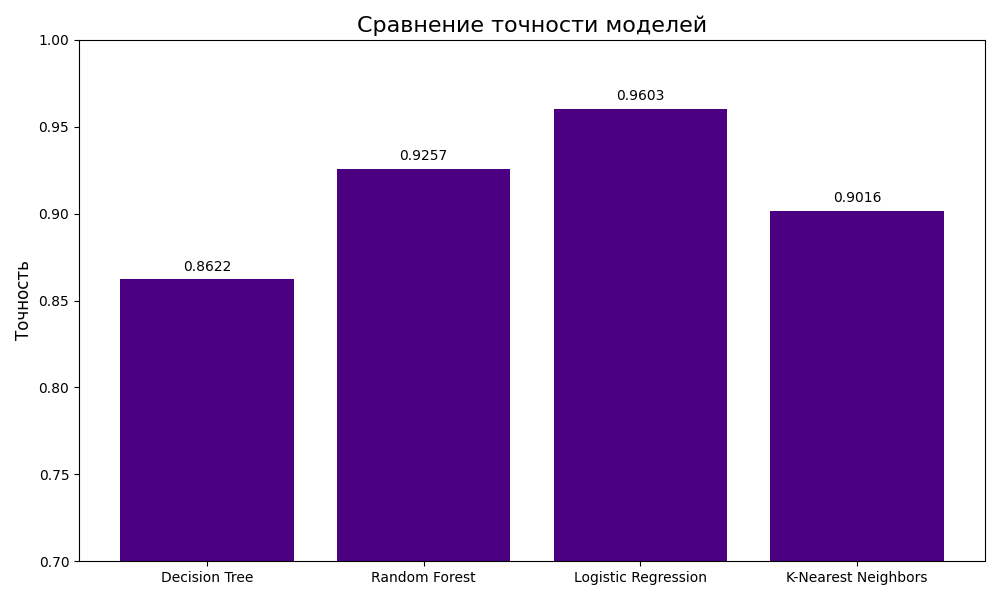

In [5]:
results = {}

for name, model in models.items():
    model.fit(train_X, train_y)
    yhat = model.predict(test_X)
    results[name] = {
        'model': model,
        'predictions': yhat,
        'accuracy': np.mean(yhat == test_y)
    }

accuracies = [results[name]['accuracy'] for name in models.keys()]

plt.figure(figsize=(10, 6))
bars = plt.bar(list(models.keys()), accuracies, color="Indigo")
plt.title('Сравнение точности моделей', fontsize=16)
plt.ylabel('Точность', fontsize=12)
plt.xticks()
plt.ylim(0.7, 1.0)

for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
        f'{accuracy:.4f}', ha='center')

plt.tight_layout()
plt.show()

Как видим, логистическая регрессия справилась лучше всего.

### Проведём более точный анализ

Decision Tree

classification_report:

                    precision    recall  f1-score   support

           Walking       0.83      0.92      0.87       496
  Walking Upstairs       0.83      0.78      0.80       471
Walking Downstairs       0.89      0.83      0.86       420
           Sitting       0.83      0.76      0.80       491
          Standing       0.80      0.86      0.83       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



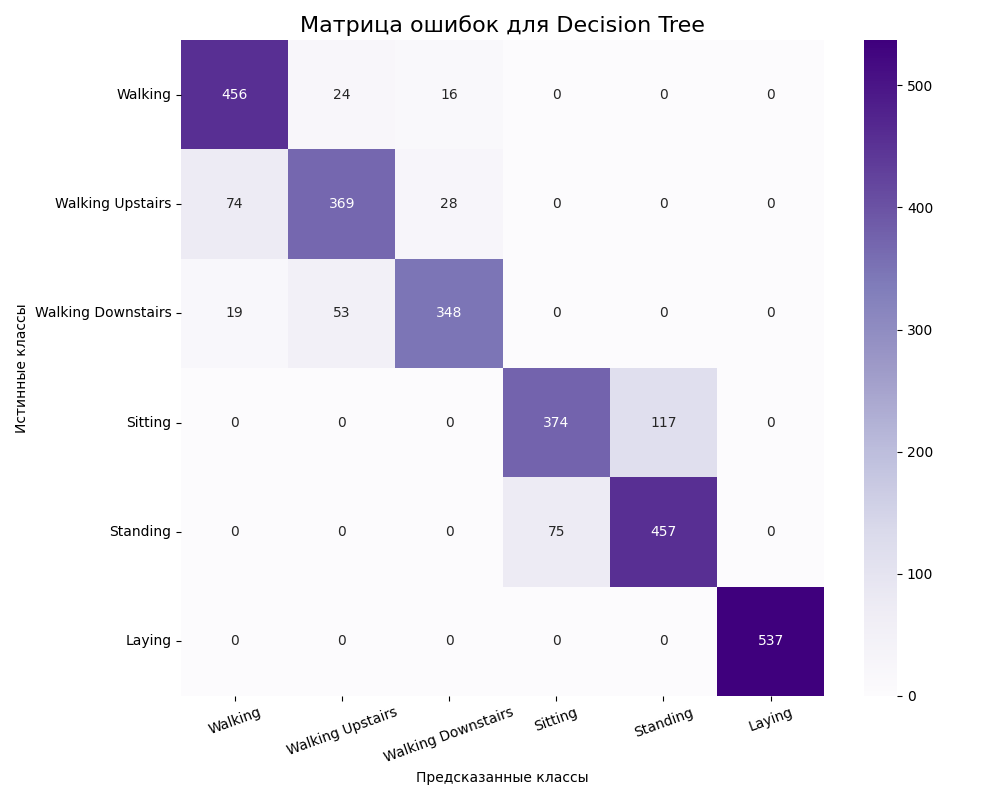

Random Forest

classification_report:

                    precision    recall  f1-score   support

           Walking       0.89      0.97      0.93       496
  Walking Upstairs       0.88      0.89      0.89       471
Walking Downstairs       0.97      0.86      0.91       420
           Sitting       0.91      0.90      0.90       491
          Standing       0.91      0.92      0.91       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



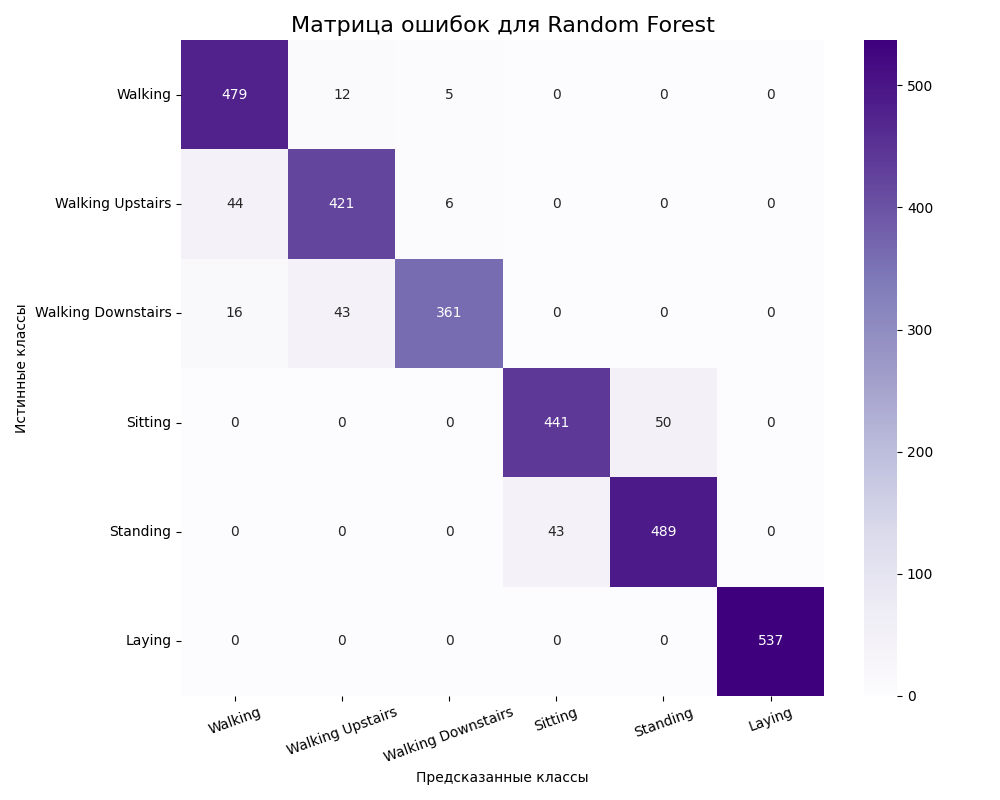

Logistic Regression

classification_report:

                    precision    recall  f1-score   support

           Walking       0.94      0.99      0.97       496
  Walking Upstairs       0.97      0.94      0.95       471
Walking Downstairs       0.99      0.96      0.98       420
           Sitting       0.98      0.88      0.93       491
          Standing       0.90      0.98      0.94       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



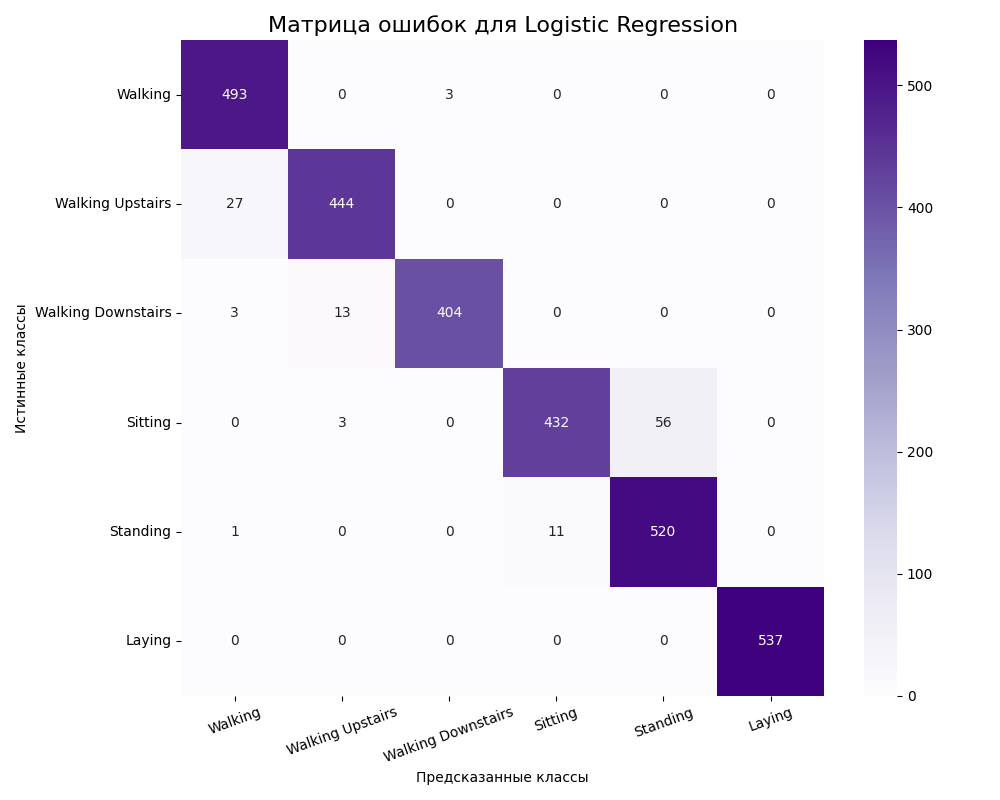

K-Nearest Neighbors

classification_report:

                    precision    recall  f1-score   support

           Walking       0.85      0.98      0.91       496
  Walking Upstairs       0.89      0.90      0.90       471
Walking Downstairs       0.95      0.79      0.86       420
           Sitting       0.91      0.79      0.85       491
          Standing       0.83      0.93      0.88       532
            Laying       1.00      0.99      1.00       537

          accuracy                           0.90      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.90      0.90      2947



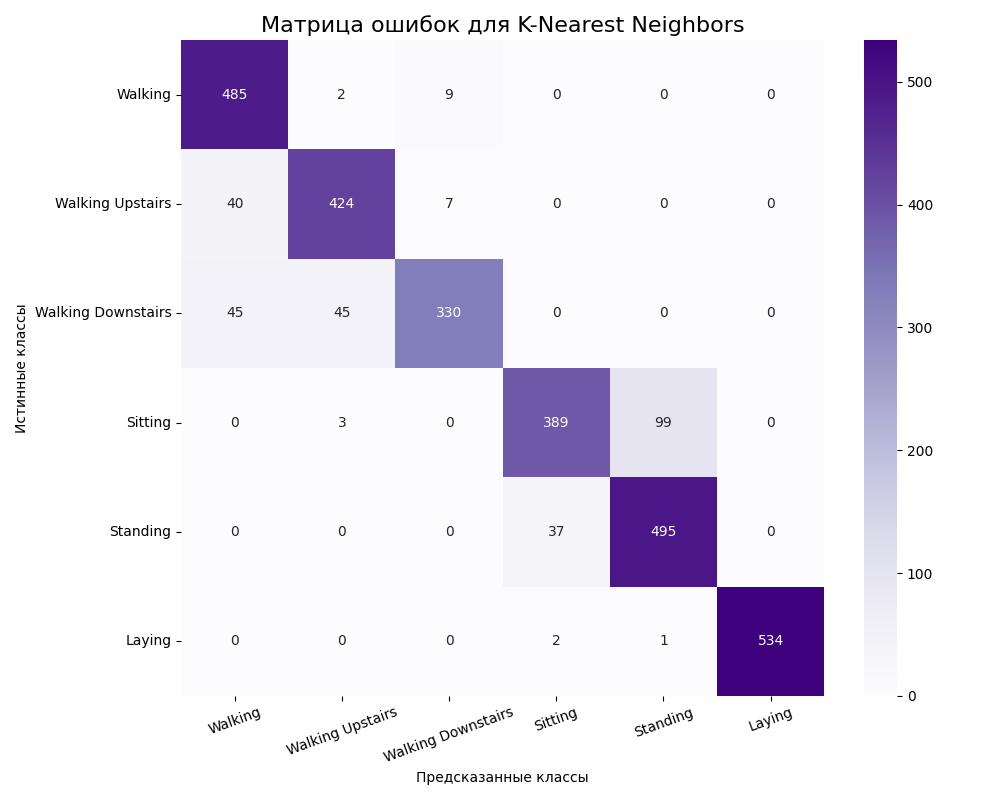

In [6]:
target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

for name in models.keys():
    print(f"{name}\n")

    print("classification_report:\n")
    print(classification_report(test_y, results[name]['predictions'], target_names=target_names))
    
    # Выводим матрицу ошибок для каждой модели
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_y, results[name]['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Матрица ошибок для {name}', fontsize=16)
    plt.xlabel('Предсказанные классы')
    plt.ylabel('Истинные классы')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

У всех моделей получилось хорошо справиться с определением положения лёжа (максимум было 3 ошибки у `KNN`). Это логично было бы предположить, потому что в таком положении человек двигается сильно меньше по сравнению с другими. А вот больше всего путаницы было с движением по лестнице и обычной ходьбой - данные с датчиков различаются между собой уже не так сильно, как при спокойном поведении и каком-либо движении. В общем, если посмотреть на матрицы ошибок, виден более общий вывод из вышесказанного - труднее отличать похожие активности человека, и чем они ближе по типу, тем больше у моделей ошибок.

#### В чем разница между показателями `precision` и `recall`? Что такое показатель `F1`?
`precision` - это точность модели, показывает сколько объектов из тех, которые модель отнесла к классу **X**, действительно принадлежат классу **X**.
$$\large \text{Precision} = \dfrac{TP}{TP + FP}$$
`recall` - полнота, показывает, сколько объектов из принадлежащих классу **X**, модель отнесла к классу **X**.
$$\text{Recall} = \dfrac{TP}{TP + FN}$$
Recall демонстрирует способность алгоритма обнаруживать данный класс вообще, а precision — способность отличать этот класс от других классов.

`F1` - среднее гармоническое между `precision` и `recall`.
$$\large F_1 = \dfrac{2\cdot\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$
#### Используем вариации нескольких моделей с разными гиперпараметрами. Сравним полученный результат (визуализируем его).

In [ ]:
from sklearn.model_selection import GridSearchCV

# Определяем параметры для каждой модели
param_grids = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 20, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 10, 100],
            'solver': ['lbfgs', 'saga']
        }
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 7, 13, 21],
            'weights': ['uniform', 'distance']
        }
    }
}

In [8]:
all_results = {}

for name, grid_info in param_grids.items():
    grid_search = GridSearchCV(
        estimator=grid_info['model'],
        param_grid=grid_info['params'],
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        return_train_score=True
    )
    
    grid_search.fit(train_X, train_y)
    
    # Сохраняем все результаты
    results_df = pd.DataFrame(grid_search.cv_results_)
    
    print(f"{name}:")
    for i, row in results_df.iterrows():
        params = row['params']
        mean_test = row['mean_test_score']
        std_test = row['std_test_score']
        print(f"   Параметры: {params}")
        print(f"\tТочность: {mean_test:.4f} +/- {std_test:.4f}\n")
    
    best_model = grid_search.best_estimator_
    best_model.fit(train_X, train_y)
    yhat = best_model.predict(test_X)
    test_accuracy = np.mean(yhat == test_y)
    
    all_results[name] = {
        'best_model': best_model,
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_accuracy': test_accuracy,
        'all_results': results_df
    }
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучшая точность кросс-валидации: {grid_search.best_score_:.4f}")
    print(f"Точность на тесте: {test_accuracy:.4f}\n")

# Сравнение всех моделей после CV-настройки
print("\nСравнение всех моделей:")
comparison = []
for name, result in all_results.items():
    comparison.append({
        'Модель': name,
        'CV точность': result['best_cv_score'],
        'Тест точность': result['test_accuracy'],
        'Параметры': str(result['best_params'])
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values('Тест точность', ascending=False)
print(comparison_df.to_string(index=False))


Decision Tree:
   Параметры: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
	Точность: 0.8293 +/- 0.0233

   Параметры: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
	Точность: 0.8293 +/- 0.0233

   Параметры: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
	Точность: 0.8293 +/- 0.0233

   Параметры: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
	Точность: 0.8293 +/- 0.0233

   Параметры: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
	Точность: 0.8293 +/- 0.0233

   Параметры: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
	Точность: 0.8293 +/- 0.0233

   Параметры: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
	Точность: 0.8288 +/- 0.0229

   Параметры: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5}
	Точность: 0.8288 +/- 0.0229

   Параметры: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
	Точность: 0.8288 +/- 0.0229

   Парамет

Визуализация

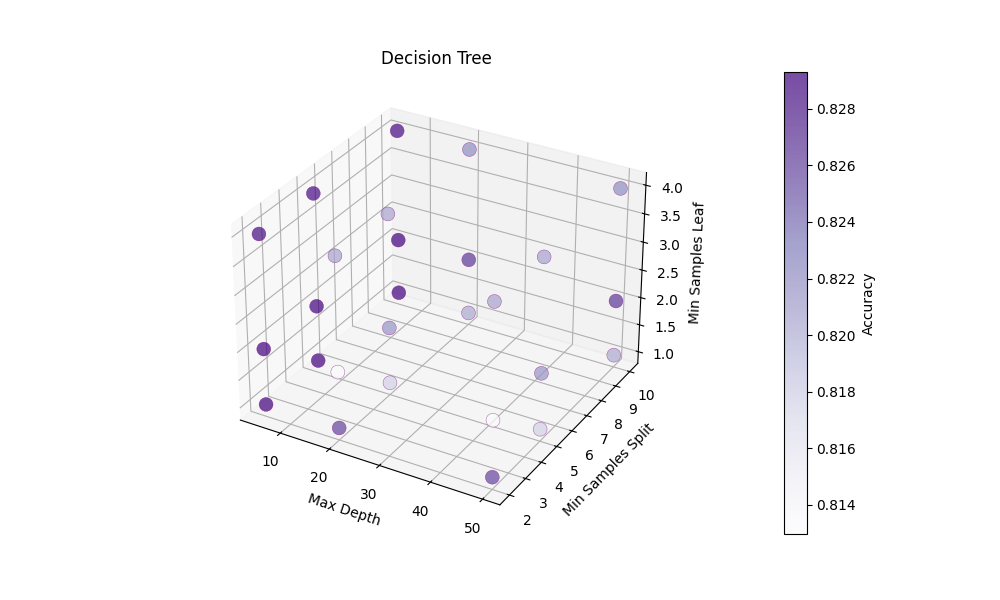

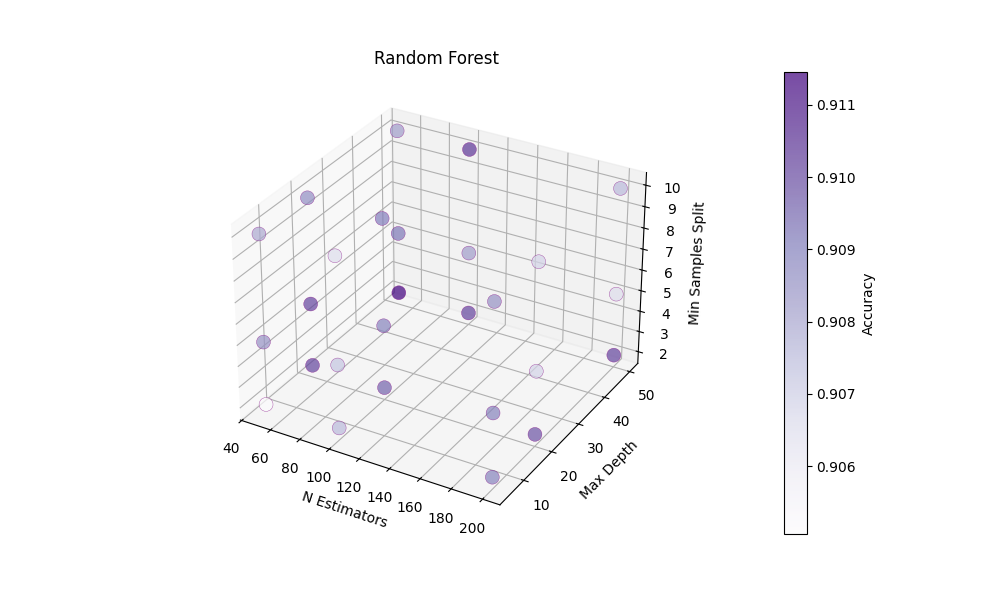

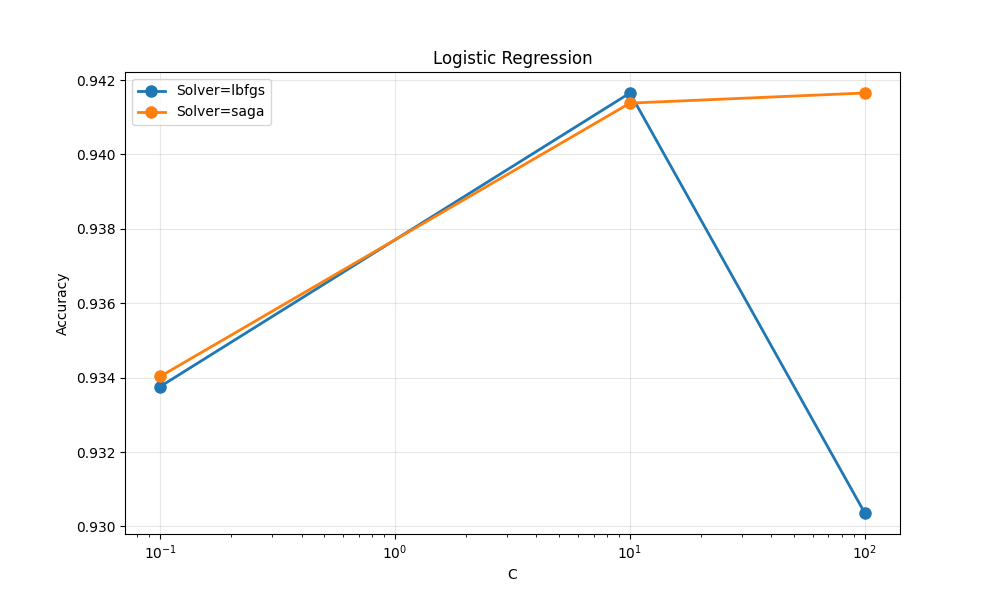

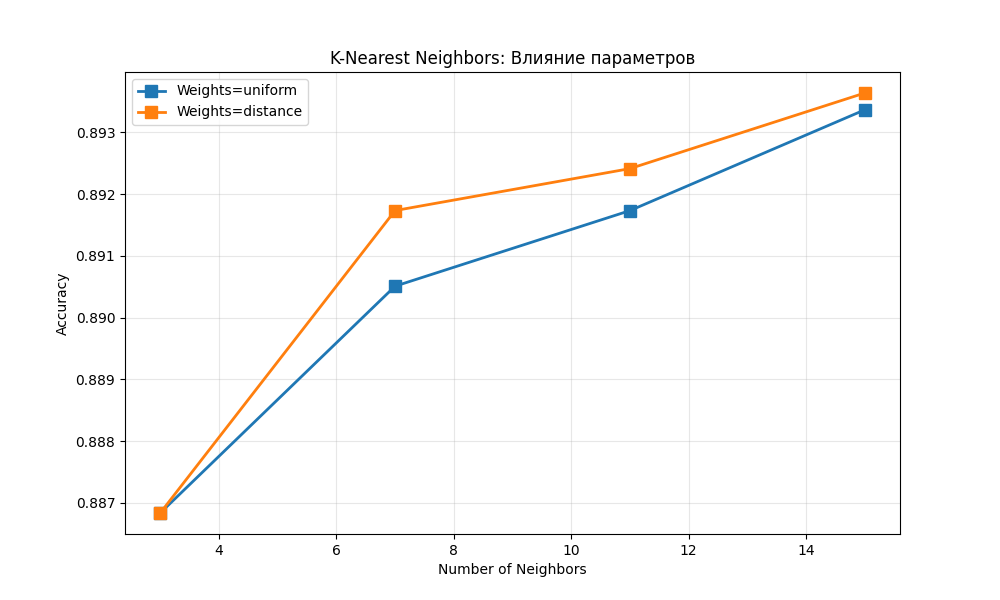

In [9]:
from mpl_toolkits.mplot3d import Axes3D

#Визуализация для Decision Tree
dt_results = all_results['Decision Tree']['all_results']

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

max_depth_vals = []
min_samples_split_vals = []
min_samples_leaf_vals = []
scores = []

for _, row in dt_results.iterrows():
    params = row['params']
    max_depth_vals.append(params['max_depth'] if params['max_depth'] else 50)
    min_samples_split_vals.append(params['min_samples_split'])
    min_samples_leaf_vals.append(params['min_samples_leaf'])
    scores.append(row['mean_test_score'])

scatter = ax.scatter(max_depth_vals, min_samples_split_vals, min_samples_leaf_vals, 
    c=scores, cmap='Purples', s=100, edgecolors="purple", linewidth=0.3, alpha=0.7)
ax.set_xlabel('Max Depth')
ax.set_ylabel('Min Samples Split')
ax.set_zlabel('Min Samples Leaf')
ax.set_title('Decision Tree')
plt.colorbar(scatter, ax=ax, label='Accuracy', pad=0.15)
plt.show()

#Визуализация для Random Forest
rf_results = all_results['Random Forest']['all_results']

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

n_estimators_vals = []
max_depth_vals = []
min_samples_split_vals = []
scores = []

for _, row in rf_results.iterrows():
    params = row['params']
    n_estimators_vals.append(params['n_estimators'])
    max_depth_vals.append(params['max_depth'] if params['max_depth'] else 50)
    min_samples_split_vals.append(params['min_samples_split'])
    scores.append(row['mean_test_score'])

scatter = ax.scatter(n_estimators_vals, max_depth_vals, min_samples_split_vals, 
    c=scores, cmap='Purples', s=100, edgecolors="purple", linewidth=0.3, alpha=0.7)
ax.set_xlabel('N Estimators')
ax.set_ylabel('Max Depth')
ax.set_zlabel('Min Samples Split')
ax.set_title('Random Forest')
plt.colorbar(scatter, ax=ax, label='Accuracy', pad=0.15)
plt.show()

#Визуализация для Logistic Regression
lr_results = all_results['Logistic Regression']['all_results']

C_vals = []
solver_vals = []
scores = []

for _, row in lr_results.iterrows():
    params = row['params']
    C_vals.append(params['C'])
    solver_vals.append(params['solver'])
    scores.append(row['mean_test_score'])

# Создаем DataFrame для удобства
lr_df = pd.DataFrame({
    'C': C_vals,
    'solver': solver_vals,
    'score': scores
})

# Группируем по solver и строим график
plt.figure(figsize=(10, 6))
for solver in lr_df['solver'].unique():
    subset = lr_df[lr_df['solver'] == solver]
    plt.plot(subset['C'], subset['score'], 'o-', label=f'Solver={solver}', linewidth=2, markersize=8)

plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

#Визуализация для K-Nearest Neighbors
knn_results = all_results['K-Nearest Neighbors']['all_results']

n_neighbors_vals = []
weights_vals = []
scores = []

for _, row in knn_results.iterrows():
    params = row['params']
    n_neighbors_vals.append(params['n_neighbors'])
    weights_vals.append(params['weights'])
    scores.append(row['mean_test_score'])

#Создаем DataFrame для удобства
knn_df = pd.DataFrame({
    'n_neighbors': n_neighbors_vals,
    'weights': weights_vals,
    'score': scores
})

#Группируем по weights и строим график
plt.figure(figsize=(10, 6))
for weight in knn_df['weights'].unique():
    subset = knn_df[knn_df['weights'] == weight]
    plt.plot(subset['n_neighbors'], subset['score'], 's-', label=f'Weights={weight}', linewidth=2, markersize=8)

plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('K-Nearest Neighbors: Влияние параметров')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Что такое гиперпараметры модели машинного обучения?
Гиперпараметры модели МО - это настраиваемые параметры, с помощью которых мы можем управлять процессом обучения.

## Выводы
В данной лабораторной работе мы научились применять и сравнивать различные модели МО, а также настраивать их гиперпараметры. Провели анализ того, как различные параметры влияют на модели, и какие модели больше подходят под нашу задачу.